In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import geopandas as gpd
import libpysal
from pysal.model import spreg
from pysal.explore import esda
import statsmodels.formula.api as smf
from shapely.geometry import Point


import matplotlib.pyplot as plt

In [3]:
master_df = pd.read_csv('aggregated data/master_file.csv')

In [4]:
#adds a geometry column for regression analysis (spatial)
geometry = [Point(xy) for xy in zip(master_df['LONG'], master_df['LAT'])]
master = gpd.GeoDataFrame(master_df, geometry=geometry)
master.crs = "EPSG:4326"

In [5]:
variables = ['Pct_VATP_11_21', 'Mig_Change', 'Health_Pct_Change', 'YAge_Pct_Change']

master_final = master.dropna(subset=variables).copy()
master_final = master_final.reset_index(drop=True)

w_final = libpysal.weights.KNN.from_dataframe(master_final, k=8)
w_final.transform = 'R'

In [6]:
master_final.head()

,LAD21CD,LAD21NM,LAD21NMW,BNG_E,BNG_N,LONG,LAT,GlobalID,Health_Pct_Change,YAge_Pct_Change,Pct_VATP_11_21,Mig_Change,geometry
0,E06000001,Hartlepool,NaN,447160,531474,-1.27018,54.6761,6497151b-869e-454f-b943-ef2e32473b9c,-1.719902,-18.333333,172.1,47.222222,POINT (-1.27018 54.6761)
1,E06000002,Middlesbrough,NaN,451141,516887,-1.21099,54.5447,30975abf-b3f8-453e-9539-4a1578310fb9,-4.199475,-18.055556,172.1,21.894110,POINT (-1.21099 54.5447)
2,E06000003,Redcar and Cleveland,NaN,464361,519597,-1.00608,54.5675,58c003e1-48b1-4b5a-a412-5dcec0794989,-3.061224,-21.238938,172.1,-2.495544,POINT (-1.00608 54.5675)
3,E06000004,Stockton-on-Tees,NaN,444940,518183,-1.30664,54.5569,8827e88c-dee1-4222-a0ed-8cc299f622a0,-0.473934,-24.793388,172.1,-8.179491,POINT (-1.30664 54.5569)
4,E06000005,Darlington,NaN,428029,515648,-1.56835,54.5353,1f43640c-1690-43a5-8ad4-925199b2e787,0.511073,-13.207547,260.5,2.724252,POINT (-1.56835 54.5353)


# Univariate 

In [7]:
#using master_final from now on
mig_umod = smf.ols("Pct_VATP_11_21 ~ Mig_Change", data = master_final)
mig_umod_fit = mig_umod.fit()
print(mig_umod_fit.summary())

                            OLS Regression Results                            
Dep. Variable:         Pct_VATP_11_21   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     3.646
Date:                Mon, 29 Dec 2025   Prob (F-statistic):             0.0572
Time:                        07:00:11   Log-Likelihood:                -1685.8
No. Observations:                 304   AIC:                             3376.
Df Residuals:                     302   BIC:                             3383.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    113.6941      3.602     31.562      0.0

In [8]:
age_umod = smf.ols("Pct_VATP_11_21 ~ YAge_Pct_Change", data = master_final)
age_umod_fit = age_umod.fit()
print(age_umod_fit.summary())

                            OLS Regression Results                            
Dep. Variable:         Pct_VATP_11_21   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.045
Method:                 Least Squares   F-statistic:                     15.36
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           0.000110
Time:                        07:00:11   Log-Likelihood:                -1680.1
No. Observations:                 304   AIC:                             3364.
Df Residuals:                     302   BIC:                             3372.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          88.6043      7.516     

In [9]:
health_umod = smf.ols("Pct_VATP_11_21 ~ Health_Pct_Change", data = master_final)
health_umod_fit = health_umod.fit()
print(health_umod_fit.summary())	

                            OLS Regression Results                            
Dep. Variable:         Pct_VATP_11_21   R-squared:                       0.018
Model:                            OLS   Adj. R-squared:                  0.015
Method:                 Least Squares   F-statistic:                     5.524
Date:                Mon, 29 Dec 2025   Prob (F-statistic):             0.0194
Time:                        07:00:11   Log-Likelihood:                -1684.9
No. Observations:                 304   AIC:                             3374.
Df Residuals:                     302   BIC:                             3381.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept           120.9266      4.44

In [10]:
mig_moran = esda.moran.Moran(master_final['Mig_Change'], w_final)
print(round(mig_moran.I,3))
print(round(mig_moran.p_sim,3))

0.049
0.031


In [11]:
age_moran = esda.moran.Moran(master_final['YAge_Pct_Change'], w_final)
print(round(age_moran.I,3))
print(round(age_moran.p_sim,3))

0.131
0.002


In [12]:
health_moran = esda.moran.Moran(master_final['Health_Pct_Change'], w_final)
print(round(health_moran.I,3))
print(round(health_moran.p_sim,3))

0.493
0.001


# Multivariate

In [13]:
all_mmod = smf.ols("Pct_VATP_11_21 ~ Mig_Change + YAge_Pct_Change + Health_Pct_Change ", data= master_final)
all_mmod_fit = all_mmod.fit()
print(all_mmod_fit.summary())

                            OLS Regression Results                            
Dep. Variable:         Pct_VATP_11_21   R-squared:                       0.079
Model:                            OLS   Adj. R-squared:                  0.070
Method:                 Least Squares   F-statistic:                     8.582
Date:                Mon, 29 Dec 2025   Prob (F-statistic):           1.75e-05
Time:                        07:00:11   Log-Likelihood:                -1675.1
No. Observations:                 304   AIC:                             3358.
Df Residuals:                     300   BIC:                             3373.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            95.2130      7.92

In [14]:
allmmod_moran = esda.moran.Moran(all_mmod_fit.resid_pearson, w_final)
print(round(allmmod_moran.I,3))
print(round(allmmod_moran.p_sim,3))

0.606
0.001


# Spatial Lag

In [15]:
variable_namemig=['Mig_Change']

lag_mig= spreg.ML_Lag(master_final[['Pct_VATP_11_21']].values,
                  master_final[variable_namemig].values,
                  w=w_final,
                  name_y='Pct_VATP_11_21',
                  name_x=variable_namemig)
print(lag_mig.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Pct_VATP_11_21                Number of Observations:         304
Mean dependent var  :    114.6707                Number of Variables   :           3
S.D. dependent var  :     62.4415                Degrees of Freedom    :         301
Pseudo R-squared    :      0.6996
Spatial Pseudo R-squared:  0.0730
Log likelihood      :  -1532.4610
Sigma-square ML     :   1214.8062                Akaike info criterion :    3070.922
S.E of regression   :     34.8541                Schwarz criterion     :    3082.073

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------------------------------

In [16]:
lag_mig_moran = esda.moran.Moran(lag_mig.u, w_final)
print(round(lag_mig_moran.I,3))
print(round(lag_mig_moran.p_sim,3))

0.075
0.006


In [17]:
variable_names = ['Mig_Change', 'Health_Pct_Change', 'YAge_Pct_Change']
lag_all = spreg.ML_Lag(master_final[['Pct_VATP_11_21']].values,
                        master_final[variable_names].values,
                        w=w_final,
                        name_y='Pct_VATP_11_21',
                        name_x=variable_names)

print(lag_all.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Pct_VATP_11_21                Number of Observations:         304
Mean dependent var  :    114.6707                Number of Variables   :           5
S.D. dependent var  :     62.4415                Degrees of Freedom    :         299
Pseudo R-squared    :      0.6984
Spatial Pseudo R-squared:  0.3058
Log likelihood      :  -1531.4823
Sigma-square ML     :   1213.0655                Akaike info criterion :    3072.965
S.E of regression   :     34.8291                Schwarz criterion     :    3091.550

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------------------------------

In [18]:
lag_all_moran = esda.moran.Moran(lag_all.u, w_final)
print(round(lag_all_moran.I,3))
print(round(lag_all_moran.p_sim,3))

0.073
0.002


# Spatial Error

In [19]:
err_mig= spreg.ML_Error(master_final[['Pct_VATP_11_21']].values,
                  master_final[variable_namemig].values,
                  w=w_final,
                  name_y='Pct_VATP_11_21',
                  name_x=variable_namemig)
print(err_mig.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
---------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Pct_VATP_11_21                Number of Observations:         304
Mean dependent var  :    114.6707                Number of Variables   :           2
S.D. dependent var  :     62.4415                Degrees of Freedom    :         302
Pseudo R-squared    :      0.0119
Log likelihood      :  -1532.3393
Sigma-square ML     :   1211.8631                Akaike info criterion :    3068.679
S.E of regression   :     34.8118                Schwarz criterion     :    3076.113

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT       136.39941  

In [20]:
err_mig_moran = esda.moran.Moran(err_mig.u, w_final)
print(round(err_mig_moran.I,3))
print(round(err_mig_moran.p_sim,3))

0.687
0.001


In [21]:
err_all = spreg.ML_Lag(master_final[['Pct_VATP_11_21']].values,
                        master_final[variable_names].values,
                        w=w_final,
                        name_y='Pct_VATP_11_21',
                        name_x=variable_names)

print(err_all.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
-----------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :Pct_VATP_11_21                Number of Observations:         304
Mean dependent var  :    114.6707                Number of Variables   :           5
S.D. dependent var  :     62.4415                Degrees of Freedom    :         299
Pseudo R-squared    :      0.6984
Spatial Pseudo R-squared:  0.3058
Log likelihood      :  -1531.4823
Sigma-square ML     :   1213.0655                Akaike info criterion :    3072.965
S.E of regression   :     34.8291                Schwarz criterion     :    3091.550

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
-------------------------------------------------------------

In [22]:
err_all_moran = esda.moran.Moran(err_all.u, w_final)
print(round(err_all_moran.I,3))
print(round(err_all_moran.p_sim,3))

0.073
0.008


# Correlation Matrix

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

vars_for_corr = ['Pct_VATP_11_21', 'Mig_Change', 'Health_Pct_Change', 'YAge_Pct_Change']

rename_dict = {
    'Pct_VATP_11_21': 'Violent Crime',
    'Mig_Change': 'Migration',
    'Health_Pct_Change': 'Bad/Very Bad Health',
    'YAge_Pct_Change': 'Age'
}

corr_matrix = master_final[vars_for_corr].corr().rename(index=rename_dict, columns=rename_dict)
print(corr_matrix)

                     Violent Crime  Migration  Bad/Very Bad Health       Age
Violent Crime             1.000000   0.109212             0.134022 -0.219969
Migration                 0.109212   1.000000            -0.131200 -0.033945
Bad/Very Bad Health       0.134022  -0.131200             1.000000 -0.028984
Age                      -0.219969  -0.033945            -0.028984  1.000000


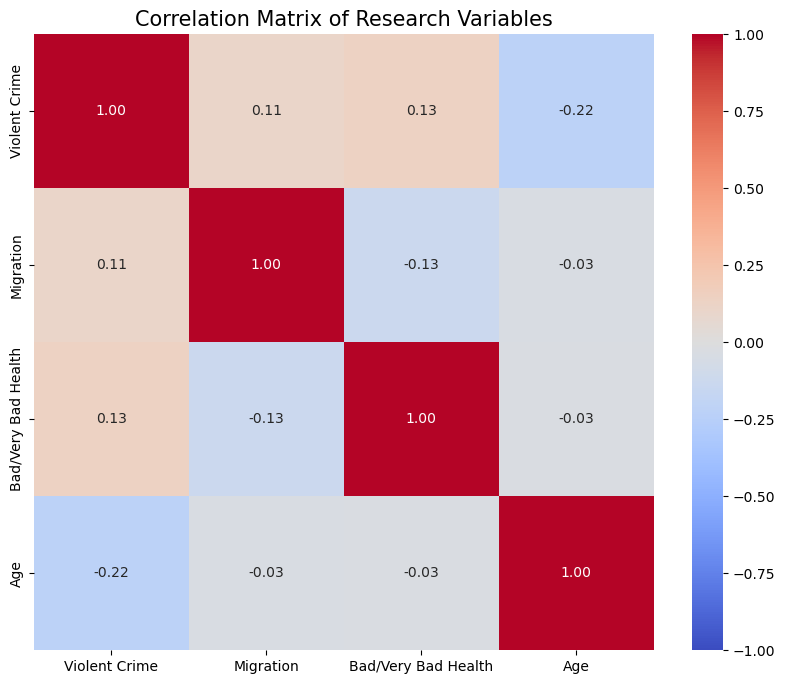

In [30]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,      
            cmap='coolwarm',  
            fmt=".2f",        
            vmin=-1, vmax=1,  
            center=0)

plt.title('Correlation Matrix of Research Variables', fontsize=15)
plt.savefig('correlation_heatmap.png')